Step 10 - 2D Poisson Equation

Here, the goal was to understand the concept of having a source term added to the Laplace equation. Depending on the problem, the source term b could represent heat generation, electric charge, fluid mass source, pressure source.

In [1]:
# importing a 3D viewer
from mpl_toolkits.mplot3d import Axes3D

# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
# creating a function for plotting our solution
def plot_solution(x, y, p): # it takes in three arguments, the x-vector, y-vector and the p(solution) matrix producing a 3D projection plot
    fig = plt.figure(figsize=(11, 7), dpi=100) # creating a figure object with a specified size and resolution
    ax = fig.add_subplot(projection='3d') # adding a subplot to the figure with 3D projection
    X, Y = np.meshgrid(x, y)
    surf = ax.plot_surface(X, Y, p[:], rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=False) # plotting the surface using the x, y and p matrices with a colormap
    
    ax.set_xlim(0, 2) # setting the limits for the x-axis
    ax.set_ylim(0, 1) # setting the limits for the y-axis
    ax.view_init(30, 225) # setting the viewing angle for the 3D plot
    ax.set_xlabel('X-axis') # labeling the x-axis
    ax.set_ylabel('Y-axis') # labeling the y-axis

In [3]:
# creating the poisson function
def poisson2d(p, ny, nx, nt, b): # it takes in five arguments, the p(solution) matrix, number of grid points in the y-direction, number of grid points in the x-direction, number of iterations and the b(source term) matrix
    pn = np.zeros((ny, nx)) # creating a 2D array of zeros for the previous iteration's solution matrix

    for i in range (nt):
        pn = p.copy() # creating a copy of the current solution matrix
        p[1:-1, 1:-1] = ((dy**2 * (pn[1:-1, 2:] + pn[1:-1, 0:-2]) + dx**2 * (pn[2:, 1:-1] + pn[0:-2, 1:-1]) - b[1:-1, 1:-1] * dx**2 * dy**2) / (2 * (dx**2 + dy**2))) # updating the solution matrix using the finite difference method
        
        # applying boundary conditions after each iteration
        p[:, nx - 1] = 0 # setting the right boundary to 0
        p[:, 0] = 0 # setting the left boundary to 0
        p[0, :] = 0 # setting the top boundary to 0
        p[ny - 1, :] = 0 # setting the bottom boundary to 0

    return p # returning the final solution matrix

In [4]:
# variables declaration
nx = 50 # number of grid points in the x-direction
ny = 50 # number of grid points in the y-direction
nt = 100 # number of iterations
xmin = 0 # minimum x-coordinate
xmax = 2 # maximum x-coordinate
ymin = 0 # minimum y-coordinate
ymax = 1 # maximum y-coordinate

dx = (xmax - xmin) / (nx - 1) # spatial step in the x-direction
dy = (ymax - ymin) / (ny - 1) # spatial step in the y-direction


# Array initialization
p = np.zeros((ny, nx)) # creating a 2D array of zeros for the solution matrix
b = np.zeros((ny, nx)) # creating a 2D array of zeros for the source term matrix


#plotting aids
x = np.linspace(xmin, xmax, nx) # creating a vector of x-coordinates
y = np.linspace(ymin, ymax, ny) # creating a vector of y-coordinates


# applying boundary conditions before the iterationS
p[:, -1] = y # setting the right boundary to y
p[:, 0] = 0 # setting the left boundary to 0
p[-1, :] = p[-2, :] # setting the top boundary to be equal to the second last row
p[0, :] = p[1, :] # setting the bottom boundary to be equal to the second row

# source term
b[int(ny / 4), int(nx / 4)] = 100 # setting a source term at a specific location in the domain
b[int(3 * ny / 4), int(3 * nx / 4)] = -100 # setting a sink term at another specific location in the domain

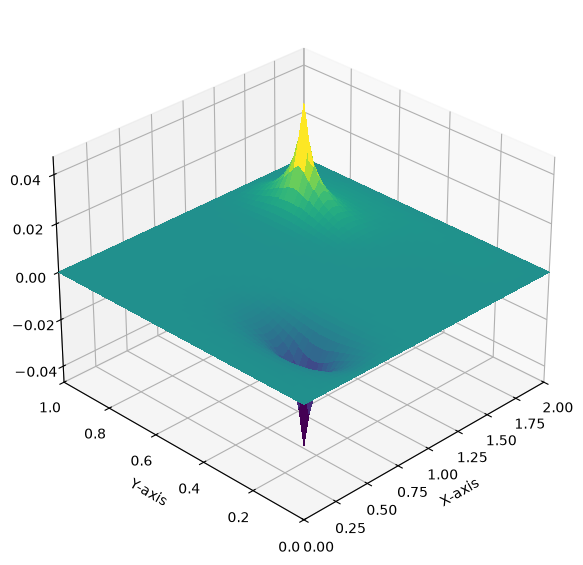

In [5]:
p = poisson2d(p, ny, nx, nt, b) # calling the poisson2d function to solve the Poisson equation

plot_solution(x, y, p) # calling the plot_solution function to visualize the solution